# Advanced Car Price Prediction Project

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
import joblib


In [2]:
df = pd.read_csv('car_data.csv')
print(df.shape)
df.head()


(301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [4]:
print(df.isnull().sum())


Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


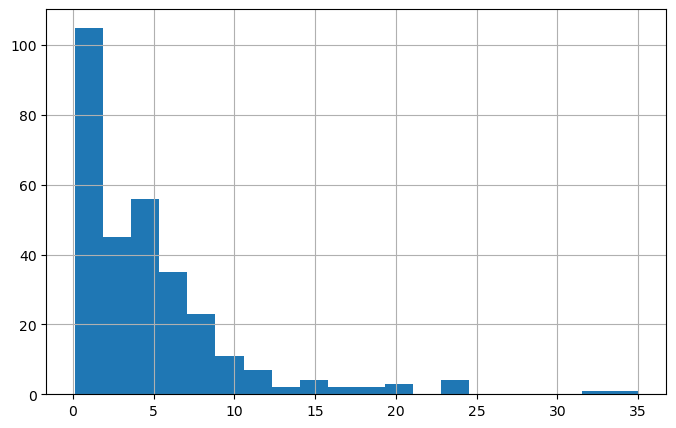

In [5]:
plt.figure(figsize=(8,5))
df['Selling_Price'].hist(bins=20)
plt.show()


In [6]:
current_year=2026
df['Car_Age']=current_year-df['Year']
df['Brand']=df['Car_Name'].apply(lambda x:x.split()[0])
df['Log_Driven_kms']=np.log1p(df['Driven_kms'])
df.drop(['Car_Name','Year'],axis=1,inplace=True)
df.head()


,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age,Brand,Log_Driven_kms
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12,ritz,10.203629
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13,sx4,10.668979
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9,ciaz,8.839422
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15,wagon,8.556606
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12,swift,10.656106


In [7]:
X=df.drop('Selling_Price',axis=1)
y=df['Selling_Price']

categorical_features=['Fuel_Type','Selling_type','Transmission','Brand']

preprocessor=ColumnTransformer(
    transformers=[('cat',OneHotEncoder(handle_unknown='ignore'),categorical_features)],
    remainder='passthrough'
)


In [8]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [9]:
models={
'Linear Regression':LinearRegression(),
'Ridge':Ridge(),
'Lasso':Lasso(),
'Decision Tree':DecisionTreeRegressor(random_state=42),
'Random Forest':RandomForestRegressor(random_state=42),
'Gradient Boosting':GradientBoostingRegressor(random_state=42),
'Extra Trees':ExtraTreesRegressor(random_state=42)
}

results=[]
for name,model in models.items():
    pipe=Pipeline([('preprocessor',preprocessor),('model',model)])
    score=cross_val_score(pipe,X,y,cv=5,scoring='r2').mean()
    results.append([name,score])

pd.DataFrame(results,columns=['Model','CV_R2']).sort_values('CV_R2',ascending=False)


,Model,CV_R2
6,Extra Trees,0.742626
5,Gradient Boosting,0.402295
4,Random Forest,0.370967
3,Decision Tree,0.210042
2,Lasso,-16.240791
1,Ridge,-18.443867
0,Linear Regression,-35.731777


In [10]:
rf_pipeline=Pipeline([
('preprocessor',preprocessor),
('model',RandomForestRegressor(random_state=42))
])

param_grid={
'model__n_estimators':[100,200,300],
'model__max_depth':[None,10,20]
}

grid=GridSearchCV(rf_pipeline,param_grid,cv=5,scoring='r2',n_jobs=-1)
grid.fit(X_train,y_train)

print(grid.best_params_)


{'model__max_depth': None, 'model__n_estimators': 100}


In [11]:
best_model=grid.best_estimator_
predictions=best_model.predict(X_test)

print('MAE:',mean_absolute_error(y_test,predictions))
print('RMSE:',np.sqrt(mean_squared_error(y_test,predictions)))
print('R2:',r2_score(y_test,predictions))


MAE: 0.6306409836065577
RMSE: 0.9117695994378276
R2: 0.9639113215587489


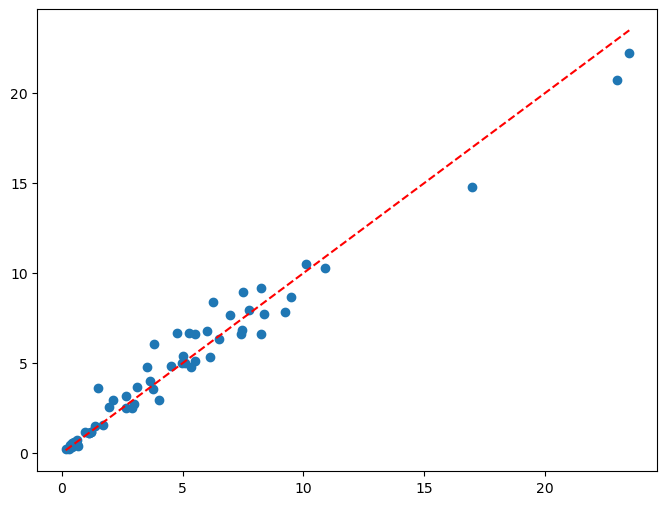

In [12]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,predictions)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')
plt.show()


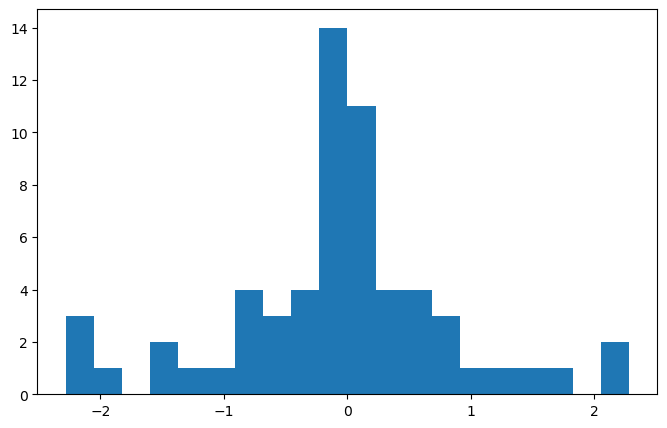

In [13]:
residuals=y_test-predictions
plt.figure(figsize=(8,5))
plt.hist(residuals,bins=20)
plt.show()


In [14]:
joblib.dump(best_model,'car_price_model.pkl')
print('Model saved')


Model saved
